In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# configuración visual
sns.set(style='whitegrid')

# cargar datos
df = pd.read_csv('../00_data/00_raw/methane_leak_dataset_realistic.csv')

df.head()

,id,status,investigateStatus,discoveredDate,estFlowRateInScfh,estFlowRateInGh,maxCh4,correlation,confidence,detectionCount,...,longitude,c2h6Ch4Ratio,backgroundCh4,gridName,surveyId,lastUpdatedBy,lastUpdatedAt,dsaRadius,nLeaks,realLeak
0,51801,NoInvestigated,ConfirmedLeak,2025-01-01 00:00:00,9.246417,0.177531,6.296290,0.985340,5.000000,6.0,...,-74.112533,0.036420,2.050115,Engativa_Grid_19,1794,carolina.martinez@searchleaks.com,2025-01-01 00:00:00,30,1,1
1,51802,NoInvestigated,NoLeak,2025-01-01 00:00:30,2.081209,0.039959,1.867654,0.328075,1.461812,1.0,...,-74.132770,0.073326,1.927944,Fontibon_Grid_8,1997,manuel.rodriguez@searchleaks.com,2025-01-01 00:00:30,50,0,0
2,51803,NoInvestigated,LikelyLeak,2025-01-01 00:01:00,66.327728,1.273492,4.265301,0.983072,5.000000,4.0,...,-74.036888,0.070250,1.994303,Usaquen_Grid_7,1562,carolina.martinez@searchleaks.com,2025-01-01 00:01:00,50,1,1
3,51804,NoInvestigated,ConfirmedLeak,2025-01-01 00:01:30,7.916194,0.151991,5.145523,0.850151,5.000000,7.0,...,-74.079401,0.036281,1.889341,Los Martires_Grid_16,1687,manuel.rodriguez@searchleaks.com,2025-01-01 00:01:30,50,1,1
4,51805,NoInvestigated,NoLeak,2025-01-01 00:02:00,0.443254,0.008510,2.069347,0.380080,1.559064,1.0,...,-74.088684,0.015341,1.989901,Suba_Grid_19,1839,manuel.rodriguez@searchleaks.com,2025-01-01 00:02:00,30,0,0


In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 22 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5000 non-null   int64  
 1   status             5000 non-null   object 
 2   investigateStatus  5000 non-null   object 
 3   discoveredDate     5000 non-null   object 
 4   estFlowRateInScfh  5000 non-null   float64
 5   estFlowRateInGh    5000 non-null   float64
 6   maxCh4             5000 non-null   float64
 7   correlation        5000 non-null   float64
 8   confidence         5000 non-null   float64
 9   detectionCount     5000 non-null   float64
 10  ch4Delta           5000 non-null   float64
 11  latitude           5000 non-null   float64
 12  longitude          5000 non-null   float64
 13  c2h6Ch4Ratio       5000 non-null   float64
 14  backgroundCh4      5000 non-null   float64
 15  gridName           5000 non-null   object 
 16  surveyId           5000 

,id,estFlowRateInScfh,estFlowRateInGh,maxCh4,correlation,confidence,detectionCount,ch4Delta,latitude,longitude,c2h6Ch4Ratio,backgroundCh4,surveyId,dsaRadius,nLeaks,realLeak
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.00000,5000.000000,5000.000000
mean,54300.500000,69.636709,1.337025,5.968954,0.797271,4.131821,4.416600,4.019482,4.688979,-74.087478,0.044969,1.949472,1497.0224,45.12400,1.011400,0.693200
std,1443.520003,83.509341,1.603379,8.191663,0.205853,1.297295,2.514818,8.193462,0.044538,0.029249,0.020386,0.086143,287.8845,9.68728,0.873741,0.461212
min,51801.000000,0.001937,0.000037,1.800162,0.300042,1.362993,1.000000,-0.291443,4.590000,-74.150000,0.010010,1.800061,1000.0000,10.00000,0.000000,0.000000
25%,53050.750000,4.008439,0.076962,2.290543,0.632318,2.655907,2.000000,0.345386,4.662323,-74.110709,0.027434,1.876872,1249.0000,40.00000,0.000000,0.000000
50%,54300.500000,45.591933,0.875365,4.012305,0.891232,5.000000,4.000000,2.075109,4.694967,-74.087910,0.044777,1.948385,1498.0000,50.00000,1.000000,1.000000
75%,55550.250000,100.897807,1.937238,6.124292,0.945957,5.000000,7.000000,4.166960,4.726057,-74.063556,0.063037,2.022930,1745.2500,50.00000,1.000000,1.000000
max,56800.000000,789.091261,15.150552,86.200848,0.999976,5.000000,10.000000,84.244994,4.780000,-74.027080,0.079993,2.099970,1999.0000,50.00000,3.000000,1.000000


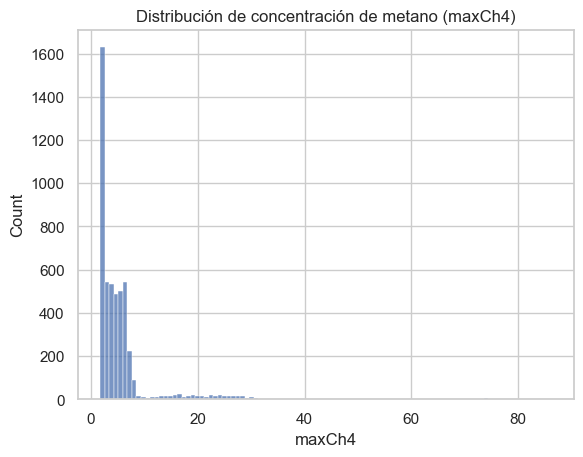

In [ ]:
plt.figure()
sns.histplot(df['maxCh4'], bins=100)
plt.title('Distribución de concentración de metano (maxCh4)')
plt.show()

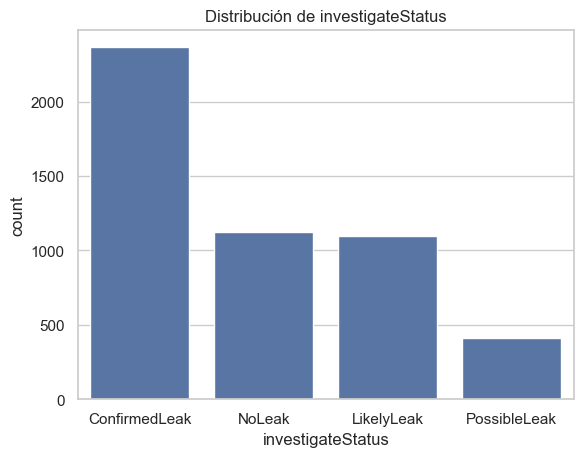

In [ ]:
plt.figure()
sns.countplot(data=df, x='investigateStatus')
plt.title('Distribución de investigateStatus')
plt.show()

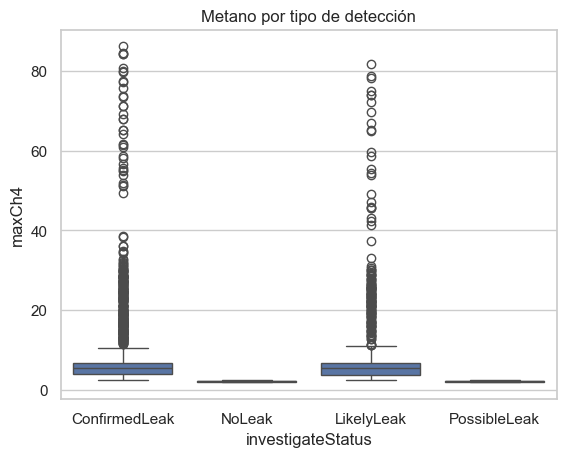

In [ ]:
plt.figure()
sns.boxplot(data=df, x='investigateStatus', y='maxCh4')
plt.title('Metano por tipo de detección')
plt.show()

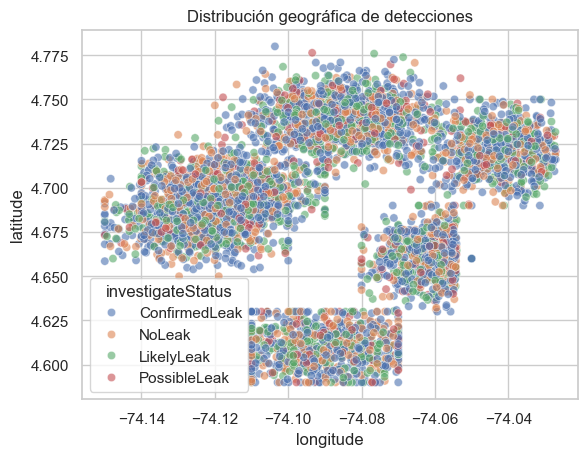

In [ ]:
plt.figure()
sns.scatterplot(
    data=df,
    x='longitude',
    y='latitude',
    hue='investigateStatus',
    alpha=0.6
)
plt.title('Distribución geográfica de detecciones')
plt.show()

In [ ]:
pd.crosstab(df['realLeak'], df['investigateStatus'])

investigateStatus,ConfirmedLeak,LikelyLeak,NoLeak,PossibleLeak
realLeak,,,,
0,0,0,1122,412
1,2366,1100,0,0


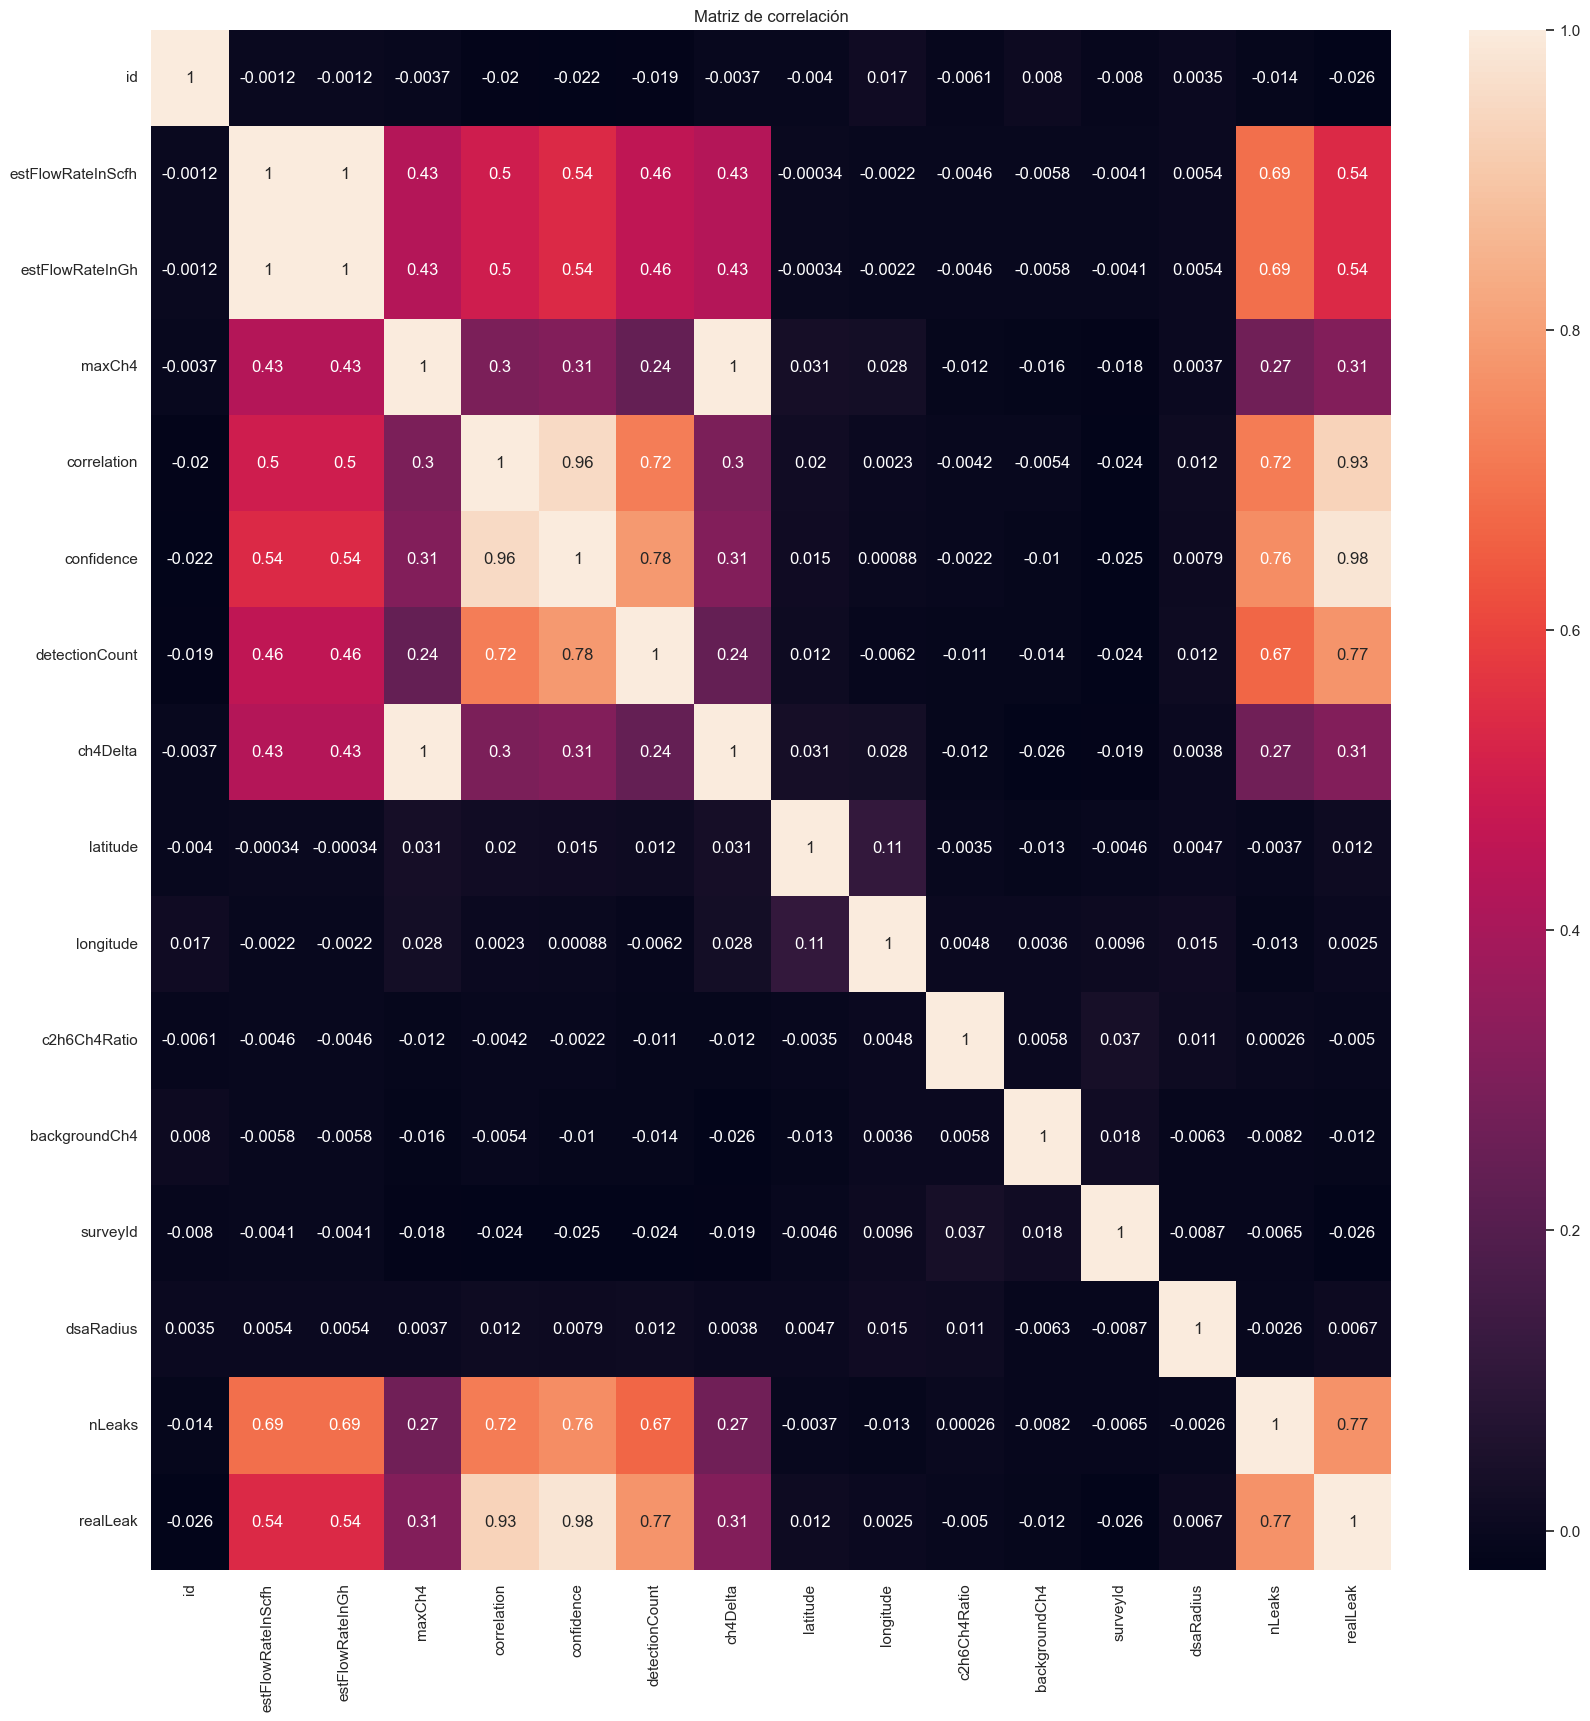

In [ ]:
plt.figure(figsize=(20, 20))
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)
plt.title('Matriz de correlación')
plt.show()

In [23]:
df[df['maxCh4'] > 50].head(10)

,id,status,investigateStatus,discoveredDate,estFlowRateInScfh,estFlowRateInGh,maxCh4,correlation,confidence,detectionCount,...,longitude,c2h6Ch4Ratio,backgroundCh4,gridName,surveyId,lastUpdatedBy,lastUpdatedAt,dsaRadius,nLeaks,realLeak
162,51963,NoInvestigated,ConfirmedLeak,2025-01-01 01:21:00,597.054922,11.463455,71.341194,0.857868,5.0,8.0,...,-74.072402,0.017227,2.019907,Los Martires_Grid_5,1520,manuel.rodriguez@searchleaks.com,2025-01-01 01:21:00,30,2,1
269,52070,NoInvestigated,ConfirmedLeak,2025-01-01 02:14:30,150.982332,2.898861,84.194273,0.985196,5.0,5.0,...,-74.065806,0.025883,1.952103,Chapinero_Grid_2,1564,carolina.martinez@searchleaks.com,2025-01-01 02:14:30,50,1,1
465,52266,NoInvestigated,ConfirmedLeak,2025-01-01 03:52:30,257.823162,4.950205,86.200848,0.922570,5.0,7.0,...,-74.110670,0.054935,1.955853,Engativa_Grid_18,1569,manuel.rodriguez@searchleaks.com,2025-01-01 03:52:30,40,2,1
523,52324,NoInvestigated,ConfirmedLeak,2025-01-01 04:21:30,232.366174,4.461431,61.589398,0.980253,5.0,9.0,...,-74.044266,0.053376,1.831010,Usaquen_Grid_14,1032,manuel.rodriguez@searchleaks.com,2025-01-01 04:21:30,50,2,1
793,52594,NoInvestigated,ConfirmedLeak,2025-01-01 06:36:30,42.635088,0.818594,60.973520,0.986188,5.0,6.0,...,-74.071219,0.025490,1.890171,Los Martires_Grid_1,1355,manuel.rodriguez@searchleaks.com,2025-01-01 06:36:30,50,1,1
876,52677,NoInvestigated,ConfirmedLeak,2025-01-01 07:18:00,191.747745,3.681557,65.274198,0.888488,5.0,5.0,...,-74.038487,0.015729,2.035315,Usaquen_Grid_12,1607,manuel.rodriguez@searchleaks.com,2025-01-01 07:18:00,50,2,1
1041,52842,NoInvestigated,ConfirmedLeak,2025-01-01 08:40:30,197.969097,3.801007,75.629597,0.860837,5.0,8.0,...,-74.067848,0.045856,1.898114,Usaquen_Grid_1,1039,manuel.rodriguez@searchleaks.com,2025-01-01 08:40:30,50,1,1
1062,52863,NoInvestigated,ConfirmedLeak,2025-01-01 08:51:00,74.556941,1.431493,61.367880,0.968676,5.0,8.0,...,-74.052610,0.039055,1.843083,Usaquen_Grid_7,1569,carolina.martinez@searchleaks.com,2025-01-01 08:51:00,50,3,1
1073,52874,NoInvestigated,LikelyLeak,2025-01-01 08:56:30,76.404349,1.466964,72.165287,0.898154,5.0,3.0,...,-74.085406,0.023587,1.806279,Suba_Grid_6,1044,andres.perez@searchleaks.com,2025-01-01 08:56:30,50,2,1
1121,52922,NoInvestigated,LikelyLeak,2025-01-01 09:20:30,75.765785,1.454703,54.341415,0.851338,5.0,4.0,...,-74.120035,0.064196,1.948061,Fontibon_Grid_18,1153,carolina.martinez@searchleaks.com,2025-01-01 09:20:30,50,1,1


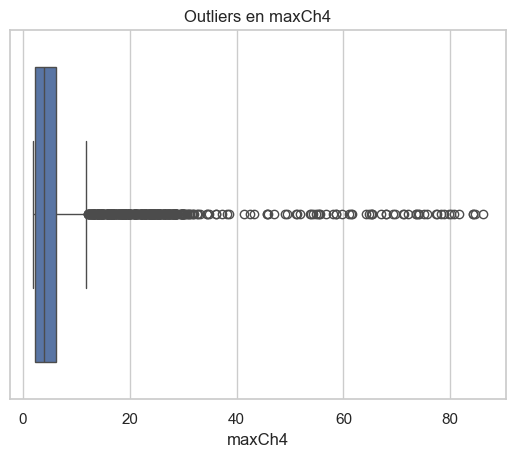

In [ ]:
plt.figure()
sns.boxplot(x=df['maxCh4'])
plt.title('Outliers en maxCh4')
plt.show()